- This notebook is based on Yann's main code from the notebook: transcribe_t_types_to_me_types.ipynb
- We will recreate all data for extended validation and new figures. 

In [1]:
from pathlib import Path

current = Path().resolve()

while not (current / ".git").exists():
    current = current.parent

PROJECT_ROOT = current

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import umap


def concatenate_dataframes(dataframes_dict):
    """
    Concatenates a dictionary of DataFrames into a single DataFrame.
    
    Parameters:
    - dataframes_dict (dict): Dictionary where keys are strings and values are DataFrames with a single column named 'density'.
    
    Returns:
    - pd.DataFrame: A single concatenated DataFrame with columns renamed to the keys of the input dictionary.
    """
    # Create an empty list to hold the renamed DataFrames
    renamed_dfs = []
    
    # Iterate over the dictionary
    for key, df in dataframes_dict.items():
        # Rename the 'density' column to the key
        renamed_df = df.rename(columns={'density_mm3': key})
        # Append the renamed DataFrame to the list
        renamed_dfs.append(renamed_df)
    
    # Concatenate all DataFrames along the columns
    concatenated_df = pd.concat(renamed_dfs, axis=1)
    
    return concatenated_df

def create_combined_dataframe(result_dataframes):
    """
    Takes a dict of dfs of different cell-type densities in brain regions (prefix) and 
    creates a dict of dfs of cell-type densities (keys) in different brain regions.
    Cell-types are also called clusters.  

    Parameters:
    - result_dataframes: dict, multiple dfs of cell-type densities in brain regions

    Returns:
    - combined_dataframes: dict of dfs where clusters are keys and brain region wise
    densities are the values. 
    """
   
    combined_dataframes = {}
    
    # Get the set of all clusters present in the result_dataframes
    all_clusters = set()
    for df in result_dataframes.values():
        all_clusters.update(df.index)
    
    # Shuffle through the dataframes and select a random cluster from each dataframe
    for cluster in all_clusters:
        selected_dfs = []
        for prefix, df in result_dataframes.items():
            if cluster in df.index:
                selected_row = df.loc[[cluster]].copy()
                # Rename the row index to the unique prefix item
                selected_row.index = [prefix]
                selected_dfs.append(selected_row)
        
        # Combine selected rows into a new DataFrame
        combined_dataframes[cluster] = pd.concat(selected_dfs)
    
    return combined_dataframes

def plot_map(data, title, filename):
    """Plot and save heatmap of data."""
    plt.figure(figsize=(60, 60))
    heatmap = plt.pcolor(data.values, cmap="jet")

    # for y in range(data.shape[0]):
    #     for x in range(data.shape[1]):
    #         if 0 < data.values[y, x] < 1.:
    #             plt.text(x + 0.5, y + 0.5, int(100 * data.values[y, x]),
    #                      horizontalalignment='center',
    #                      verticalalignment='center')

    plt.colorbar(heatmap)
    plt.xticks(np.arange(len(data.columns)) + .5, data.columns, rotation=90)
    plt.yticks(np.arange(len(data.index)) + .5, data.index)
    plt.title(title)
    # plt.savefig(filename)

In [6]:
# First we read in the conversion matrix from t-type to me-types
extended_p_me_t = pd.read_csv(PROJECT_ROOT / "extension/extended_p_me_t.csv", index_col=0)
extended_p_me_t.head()

,IN_DEND_0_AX_0|bAC,IN_DEND_0_AX_3|bAC,IN_DEND_0_AX_4|bAC,IN_DEND_0_AX_5|bAC,IN_DEND_0_AX_6|bAC,IN_DEND_0_AX_8|bAC,IN_DEND_0_AX_9|bAC,IN_DEND_1_AX_0|bAC,IN_DEND_1_AX_2|bAC,IN_DEND_1_AX_3|bAC,...,IN_DEND_6_AX_9|dSTUT,IN_DEND_7_AX_0|dSTUT,IN_DEND_7_AX_2|dSTUT,IN_DEND_7_AX_3|dSTUT,IN_DEND_7_AX_8|dSTUT,IN_DEND_8_AX_8|dSTUT,IN_DEND_9_AX_1|dSTUT,IN_DEND_9_AX_2|dSTUT,IN_DEND_9_AX_5|dSTUT,IN_DEND_9_AX_8|dSTUT
0042_L6_IT_CTX_Glut_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0049_L6_IT_CTX_Glut_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0063_L5_IT_CTX_Glut_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0247_LA-BLA-BMA-PA_Glut_5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0288_CA1-ProS_Glut_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Check if all rows add up to 1
np.allclose(np.sum(extended_p_me_t, axis=1), 1.0)

True

In [9]:
# #Next, we load the t-type density file, part of the repo
# data = pd.read_pickle('scaled_densities_t_types_as_keys.pickle')
# sorted_dict = {k: data[k] for k in sorted(data)}

# # We will concatenate the dict of df into a single df and remove 2nd index from items. this has the same shape as in the noebook example
# # densities_df = concatenate_dataframes(sorted_data)
# densities_df = pd.concat({k: v.iloc[:, 0] for k, v in sorted_dict.items()}, axis=1)
# densities_df.shape

data = pd.read_pickle(PROJECT_ROOT / 'densities_app/scaled_densities_new.pickle')
sorted_dict = {k: data[k] for k in sorted(data)}
densities_df = pd.concat({k: v.iloc[:, 0] for k, v in sorted_dict.items()}, axis=1).T
densities_df.shape

(719, 5274)

In [10]:
densities_df.head(3)

cluster,0023 L5/6 IT TPE-ENT Glut_1,0093 L4/5 IT CTX Glut_4,0150 L2/3 IT PIR-ENTl Glut_3,0205 MEA Slc17a7 Glut_2,0207 MEA Slc17a7 Glut_2,0239 LA-BLA-BMA-PA Glut_3,0240 LA-BLA-BMA-PA Glut_3,0402 NLOT Rho Glut_1,0498 HPF CR Glut_1,0518 OB Meis2 Thsd7b Gaba_1,...,4606 Pineal Crx Glut_1,5261 Ependymal NN_2,1748 ZI Pax6 Gaba_4,1763 ZI Pax6 Gaba_7,1786 ZI Pax6 Gaba_11,4531 NTS Dbh Glut_1,3859 SNc-VTA-RAmb Foxa1 Dopa_3,4452 CU-ECU-SPVI Foxb1 Glut_1,4208 PRP-NI-PRNc-GRN Otp Glut_2,4580 SPVC Ccdc172 Glut_1
AAA,395.086290,251.418548,35.916935,2621.936289,35.916935,35.916935,215.501613,2011.348386,35.916935,179.584677,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACAd1,19.273986,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACAd23,425.969136,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
densities_df.index[densities_df.index.str.contains("unassigned")]
#len(densities_df.index[densities_df.index.str.contains("unassigned")])

Index(['CBunassigned', 'CTXspunassigned', 'HPFunassigned', 'HYunassigned',
       'IIInunassigned', 'IInunassigned', 'IPNunassigned', 'MBunassigned',
       'MOBunassigned', 'MYunassigned', 'OLFunassigned', 'PAGunassigned',
       'PALunassigned', 'PBunassigned', 'Punassigned', 'STRunassigned',
       'THunassigned', 'V3unassigned', 'V4unassigned', 'VIInunassigned',
       'VLunassigned', 'ZIunassigned', 'brainunassigned', 'cstunassigned',
       'fibertractsunassigned', 'rustunassigned', 'scwmunassigned',
       'unassigned'],
      dtype='object')

In [12]:
# Create a dict of the t-type names and rename column names
t_tpes_dict = {x: x.replace(" ", "_") for x in densities_df.columns}
densities_df = densities_df.rename(t_tpes_dict, axis=1)
#densities_df.head(3)

In [13]:
# Next, we select for t-types present in both files: extended_p_me_t, densities_df (columns are being removed from densities_df)
# This reduces the cell type numbers from 5274 to 5120..
common_t_types = extended_p_me_t.index.intersection(densities_df.columns)

# We create a mask for "IMN" and "NN" types 
# This foes not do anything, because all IMN and NN types were removed in the line above, see: densities_df.columns.difference(extended_p_me_t.index)
# NN stands for non-neuronal and IMN = immature neuronal types
msk_t_types = np.asarray([("IMN" not in x) & ("NN" not in x) for x in common_t_types])
common_t_types = common_t_types[msk_t_types]

# We reindex the cell type names in both files
extended_p_me_t = extended_p_me_t.reindex(common_t_types, axis=0)
densities_df = densities_df.reindex(common_t_types, axis=1)
densities_df.shape

(719, 5120)

In [14]:
# msk_t_type contains only those t-types that have at least one non-zero value in extended_p_me_t.
msk_t_type = common_t_types[extended_p_me_t.T.fillna(0).sum() > 0]
# It does not do anything
# It is probably a sanity check to not include cell types that do not exist
np.array_equal(common_t_types, msk_t_type), common_t_types.shape, msk_t_type.shape


(True, (5120,), (5120,))

In [15]:
# We reindex both files with the non-zero type names, does not do anything
extended_p_me_t = extended_p_me_t.reindex(msk_t_type, axis=0)
densities_df = densities_df.reindex(msk_t_type, axis=1)
densities_df.shape

(719, 5120)

In [16]:
# Show all neurotransmitters in the names
np.unique(np.asarray([x.split("_")[-2] for x in common_t_types]))

array(['Chol', 'Dopa', 'Dopa-Gaba', 'Gaba', 'Gaba-Chol', 'Gaba-Glut',
       'Glut', 'Glut-Chol', 'Glut-Sero', 'Gly-Gaba', 'Glyc-Gaba',
       'Hist-Gaba'], dtype='<U9')

In [17]:
# Normalization step: Each row sums to 1, Values become fractions / probabilities
# Relative composition within each row is preserved
extended_p_me_t = extended_p_me_t.div(np.sum(extended_p_me_t, axis=1), axis=0)
extended_p_me_t.shape

(5120, 458)

In [18]:
# Remove unassigned brain regions from the dfs
t_types_densities = densities_df[~densities_df.index.str.contains('unassigned')].fillna(0)

# matrix multiplication step between the 2 dfs 
me_types_densities = t_types_densities @ extended_p_me_t.fillna(0)

densities_df.shape, t_types_densities.shape, me_types_densities.shape

((719, 5120), (691, 5120), (691, 458))

In [24]:
# We do not Remove unassigned brain regions from the dfs
t_types_densities_unassignes = densities_df.fillna(0)
me_with_unassigned = t_types_densities_unassignes @ extended_p_me_t.fillna(0)

# Split the column names to separate "m-type" and "e-type"
me_with_unassigned.columns = pd.MultiIndex.from_tuples([col.split('|') for col in me_with_unassigned.columns], names=['m-type', 'e-type'])
me_with_unassigned.to_csv(PROJECT_ROOT / "extension/data/brain__with_unassigned_regions_me_types_composition.csv")


# Sum the columns within each "e-type" group
e_types_densities_unassigned = me_with_unassigned.T.groupby(level='e-type').sum().T

# Sum the columns within each "m-type" group
m_types_densities_unassigned = me_with_unassigned.T.groupby(level='m-type').sum().T

e_types_densities_unassigned.to_csv(PROJECT_ROOT / "extension/data/brain__with_unassigned_regions_e_types_composition.csv")
m_types_densities_unassigned.to_csv(PROJECT_ROOT / "extension/data/brain__with_unassigned_regions_m_types_composition.csv")

me_with_unassigned.shape, m_types_densities_unassigned.shape, e_types_densities_unassigned.shape

((719, 458), (719, 60), (719, 11))

In [25]:
me_with_unassigned.sum()

m-type          e-type
IN_DEND_0_AX_0  bAC        23705.266602
IN_DEND_0_AX_3  bAC       591148.144233
IN_DEND_0_AX_4  bAC       702173.694775
IN_DEND_0_AX_5  bAC       131880.649941
IN_DEND_0_AX_6  bAC       105752.270774
                              ...      
IN_DEND_8_AX_8  dSTUT      62042.497439
IN_DEND_9_AX_1  dSTUT      22563.314589
IN_DEND_9_AX_2  dSTUT      33847.814005
IN_DEND_9_AX_5  dSTUT      19138.078972
IN_DEND_9_AX_8  dSTUT      33477.582639
Length: 458, dtype: float64

CPU times: user 6.53 s, sys: 169 ms, total: 6.7 s
Wall time: 6.7 s


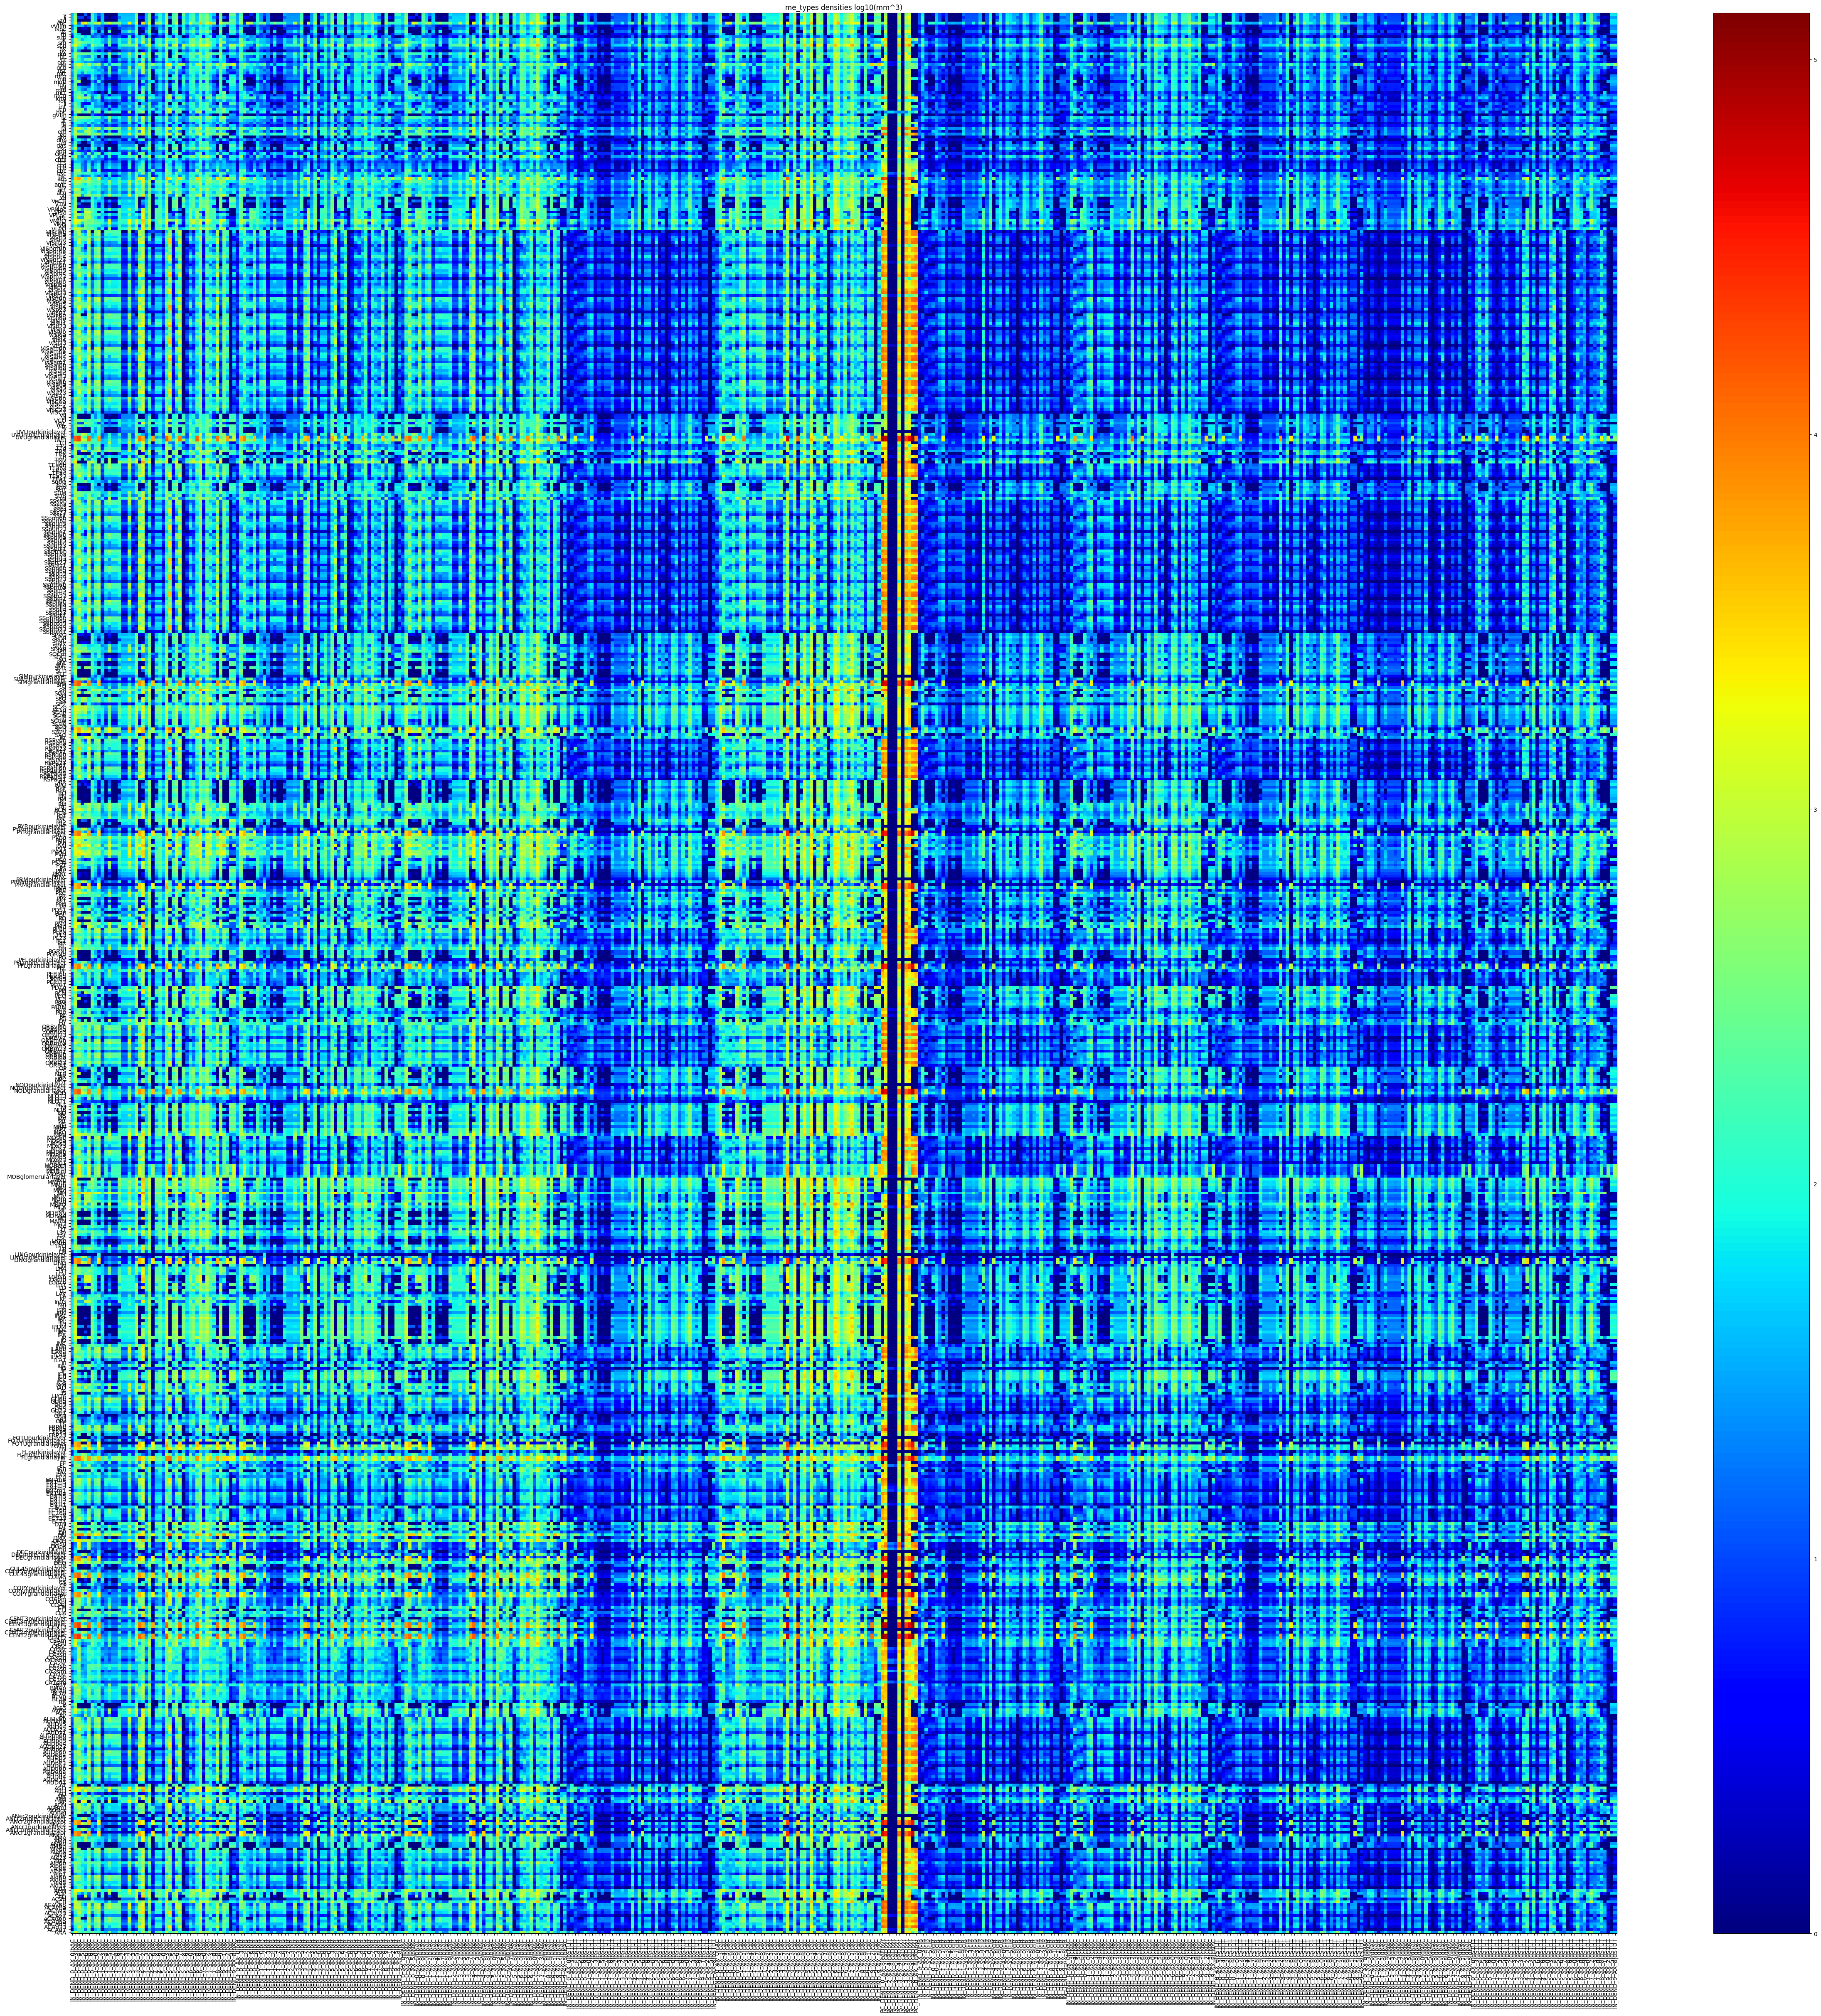

In [26]:
%%time

plot_map(np.log10(me_types_densities + 1.), "me_types densities log10(mm^3)", "me_types_densities.png")

### Goals to save the data 

- 1️⃣ Split column names into a MultiIndex
- 2️⃣ Sum densities by e-type
- 3️⃣ Sum densities by m-type 

In [27]:
# Split the column names to separate "m-type" and "e-type"
me_types_densities.columns = pd.MultiIndex.from_tuples([col.split('|') for col in me_types_densities.columns], names=['m-type', 'e-type'])

# Sum the columns within each "e-type" group
e_types_densities = me_types_densities.T.groupby(level='e-type').sum().T

# Sum the columns within each "m-type" group
m_types_densities = me_types_densities.T.groupby(level='m-type').sum().T

me_types_densities.shape, m_types_densities.shape, e_types_densities.shape

((691, 458), (691, 60), (691, 11))

In [28]:
# Save me-types here:
me_types_densities.to_csv(PROJECT_ROOT / "extension/data/brain_regions_me_types_composition.csv")
e_types_densities.to_csv(PROJECT_ROOT / "extension/data/brain_regions_e_types_composition.csv")
m_types_densities.to_csv(PROJECT_ROOT / "extension/data/brain_regions_m_types_composition.csv")

## End of important part

In [29]:
# How to find cell types
type(me_types_densities.columns)


pandas.core.indexes.multi.MultiIndex

In [30]:
me_types_densities[["PC_DEND_1_AX_7", "PC_DEND_0_AX_8"]]

m-type,PC_DEND_1_AX_7,PC_DEND_0_AX_8
e-type,cADpyr,cADpyr
AAA,2880.993266,1300.093245
ACAd1,947.632402,1322.400861
ACAd23,8713.327535,13457.965652
ACAd5,6165.416213,5563.744221
ACAd6a,7923.591979,9482.823536
...,...,...
vVIIIn,159.351412,9.020815
vhc,1305.011468,167.356042
vtd,503.980030,0.000000


# Open Pickle files

In [11]:
#Next, we load the t-type density file, part of the repo
data = pd.read_pickle('scaled_densities_t_types_as_keys.pickle')
sorted_dict = {k: data[k] for k in sorted(data)}
df1 = pd.concat({k: v.iloc[:, 0] for k, v in sorted_dict.items()}, axis=1)
df1.shape

(703, 5274)

In [12]:
data = pd.read_pickle('scaled_densities_new.pickle')
sorted_dict = {k: data[k] for k in sorted(data)}
df2 = pd.concat({k: v.iloc[:, 0] for k, v in sorted_dict.items()}, axis=1).T
df2.shape


(719, 5274)

In [16]:
len(list(df1.T.columns.difference(df2.T.index)))

703

In [18]:
missing_in_df1 = df2.index.difference(df1.index)
missing_in_df1

Index(['ANcr1', 'ANcr2', 'CENT2', 'CENT3', 'COPY', 'CUL45', 'DEC', 'FL',
       'FOTU', 'LING', 'NOD', 'PFL', 'PRM', 'PYR', 'SIM', 'UVU'],
      dtype='object')